**OverLeaf**: https://www.overleaf.com/project/69b8a90c2455d607134296d9

# Forecasting Final Project
## S&P 500 Energy Sector Index (S5ENRS) Trading Strategies
### Econ 409 | University of California, Los Angeles
Jacob Williams · Praus Paek · Joshua Kenworthy · Agnibha Bhattacharya · Ignacio Ramirez

---

## 1. Introduction

The S&P 500 Energy Sector Index (S5ENRS) tracks U.S. large-cap energy companies and exhibits valuation cycles that often persist for several years, driven by commodity price dynamics, interest rate conditions, and broad market sentiment. This project constructs and evaluates two systematic weekly trading strategies for S5ENRS using a fundamentals-based fair value gap framework.

Rather than relying on price momentum or technical indicators, both strategies model fair value as a function of observable inputs — the U.S. 1-year Treasury yield, the S&P 500 forward P/E ratio, and the S&P 500 trailing P/E ratio — and generate signals when the observed price deviates substantially from that modelled fair value. The economic premise is that persistent deviations from fundamentals-implied fair value tend to partially mean-revert over subsequent periods.

Two estimation approaches are compared. The first uses a rolling OLS regression with a fixed trailing window, allowing the fair value relationship to adapt to recent data. The second uses a Kalman filter with time-varying coefficients, allowing the relationship to evolve continuously over time. Both strategies allow long, flat, and short weekly positions.

Performance is evaluated out-of-sample over approximately eight years (January 2018 – February 2026). The S&P 500 Index serves as the broad market benchmark; the S5ENRS buy-and-hold provides the sector-specific reference. Hyperparameters were selected using the training sample only; the test period was not used at any point during model development.

---

## 2. Strategy and Conceptual Framework

### Fundamental Inputs

Three observable variables serve as proxies for the fundamental value of the S5ENRS Index.

**U.S. 1-year Treasury yield (`t1y`).** Short-term rates affect equity valuations through the discount rate channel. Higher rates compress P/E multiples by raising the hurdle rate for equity returns. The energy sector is sensitive to this mechanism through both financing costs and broader economic demand conditions.

**S&P 500 forward P/E (`sp500_best_pe`).** The consensus forward P/E reflects market-wide earnings expectations. When broad market optimism is elevated, energy sector valuations tend to follow, creating scope for mean-reversion when the sector diverges from the broader trend.

**S&P 500 trailing P/E (`sp500_pe`).** The trailing P/E captures the relationship between realised earnings and current prices. Together with the forward P/E, it characterises the gap between market expectations and actual fundamentals.

The S&P 500 price level (`sp500_price`) is used only as a performance benchmark and does not enter any signal computation.

### Strategy 1: Rolling Regression Fair Value Gap

At each week $t$, a rolling OLS regression of $\log(\text{S5ENRS}_t)$ on the selected inputs is estimated using the preceding $W$ observations. The regression coefficients are estimated from data through $t-1$; the fitted log fair value at $t$ is then computed by applying those coefficients to the current-period inputs, all of which are observable at week $t$. The fair value gap is the signed difference between observed and fitted log price, standardised by an expanding-window z-score. A long position is entered when the gap is sufficiently negative (price below fair value), a short position when the gap is sufficiently positive, and a flat position otherwise. The rolling window allows the fair value relationship to adapt to changing regimes.

### Strategy 2: Kalman Filter Fair Value Gap

The Kalman filter re-estimates the same regression in a state-space framework where the coefficient vector evolves as a random walk. At each $t$, the fair value estimate is the one-step-ahead prediction — the projection of $\log(\text{S5ENRS}_t)$ formed before incorporating the current-period observation. This is leakage-safe by construction. The same z-score threshold rule converts the gap into a directional signal.

### Position Space

Both strategies allow three positions: long ($+1$), flat ($0$), and short ($-1$). The flat position is taken when the standardised gap falls within the threshold band. This avoids forcing continuous exposure when the model does not produce a sufficiently clear signal, which is economically relevant for an energy sector strategy where the fundamental relationship may be temporarily unstable.

---

## 3. Leakage Prevention and Backtest Rules

The following constraints are enforced throughout all data preparation, signal construction, and backtesting steps. Violations of any of these rules would invalidate the backtest.

1. **Information timing.** All signals are formed exclusively from information available at time $t$. No observation from period $t+1$ or later may enter the signal computation for period $t$.

2. **Trade execution lag.** Signals formed using information through week $t$ are applied to the return realized over week $t+1$. No same-period return is used in strategy evaluation.

3. **No full-sample normalization.** Standardization, scaling, or normalization of any input series is performed only on data available up to and including $t$, using expanding or rolling statistics computed strictly in-sample. Full-sample statistics (e.g., z-scoring on the entire dataset) are prohibited.

4. **No test-set hyperparameter tuning.** All model hyperparameters (e.g., Kalman filter noise ratios, regression window lengths, signal thresholds) are selected using the training set only. The test set is not touched during model selection.

5. **No future observations in rolling or expanding calculations.** All rolling windows, expanding windows, and recursive estimators are configured with `min_periods` and applied strictly forward in time. No `.shift(-k)` for $k > 0$ may appear on the right-hand side of any feature computation.

6. **Benchmark separation.** The S&P 500 price series (`sp500_price`) is used only for performance benchmarking after strategy signals are finalized. It does not enter any forecasting model as an input or feature.

---

## 4. Methodology

### 4.1 Data and Variable Definitions

Five daily time series are loaded from local CSV files exported from Bloomberg. Each file uses a distinct date format, so date parsing is handled individually per file rather than applying a single global format.

| Variable | Source file | Role |
|---|---|---|
| `enrs` | S5ENGS.csv | Tradable asset: S&P 500 Energy Sector Index daily last price |
| `t1y` | H15T1Y.csv | Forecasting input: U.S. 1-year Treasury yield (%) |
| `sp500_best_pe` | SP500 Best PE.csv | Forecasting input: S&P 500 forward (consensus) P/E ratio |
| `sp500_pe` | SP500 PE.csv | Forecasting input: S&P 500 trailing P/E ratio |
| `sp500_price` | SP500 Price.csv | Benchmark only: S&P 500 Index daily last price |

**Date format note.** `S5ENGS.csv` uses `M/D/YYYY` (e.g., `2/27/2026`). All four SP500 and US Treasury files use `DD/MM/YYYY` (e.g., `27/02/2026`). Using an incorrect format on either group would silently produce wrong dates for months ≤ 12. Explicit `format` strings are passed to `pd.to_datetime` for each file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
enrs = pd.read_csv('S5ENGS.csv')
enrs.columns = enrs.columns.str.strip()
enrs = enrs.rename(columns={'S5ENRS Index - Last Price': 'enrs'})
enrs['date'] = pd.to_datetime(enrs['Date'], format='%m/%d/%Y', errors='coerce')
enrs['enrs'] = pd.to_numeric(enrs['enrs'], errors='coerce')
enrs = enrs[['date', 'enrs']].dropna().sort_values('date').reset_index(drop=True)
display(enrs.head(3))

,date,enrs
0,1989-09-11,82.968
1,1989-09-12,83.837
2,1989-09-13,83.164


In [3]:
t1y = pd.read_csv('SP 500 and US Treasury/H15T1Y.csv')
t1y.columns = t1y.columns.str.strip()
t1y = t1y.rename(columns={'Last Price': 't1y'})
t1y['date'] = pd.to_datetime(t1y['Date'], format='%d/%m/%Y', errors='coerce')
t1y['t1y'] = pd.to_numeric(t1y['t1y'], errors='coerce')
t1y = t1y[['date', 't1y']].dropna().sort_values('date').reset_index(drop=True)
display(t1y.head(3))

,date,t1y
0,1988-03-31,6.76
1,1988-04-04,7.00
2,1988-04-05,7.04


In [4]:
bpe = pd.read_csv('SP 500 and US Treasury/SP500 Best PE.csv')
bpe.columns = bpe.columns.str.strip()
bpe = bpe.rename(columns={'BEst P/E Ratio': 'sp500_best_pe'})
bpe['date'] = pd.to_datetime(bpe['Date'], format='%d/%m/%Y', errors='coerce')
bpe['sp500_best_pe'] = pd.to_numeric(bpe['sp500_best_pe'], errors='coerce')
bpe = bpe[['date', 'sp500_best_pe']].dropna().sort_values('date').reset_index(drop=True)
display(bpe.head(3))

,date,sp500_best_pe
0,1990-04-03,13.1553
1,1990-04-04,13.0576
2,1990-04-05,13.0560


In [5]:
pe = pd.read_csv('SP 500 and US Treasury/SP500 PE.csv')
pe.columns = pe.columns.str.strip()
pe = pe.rename(columns={'Price Earnings Ratio (P/E)': 'sp500_pe'})
pe['date'] = pd.to_datetime(pe['Date'], format='%d/%m/%Y', errors='coerce')
pe['sp500_pe'] = pd.to_numeric(pe['sp500_pe'], errors='coerce')
pe = pe[['date', 'sp500_pe']].dropna().sort_values('date').reset_index(drop=True)
display(pe.head(3))

,date,sp500_pe
0,1990-05-10,14.6651
1,1990-05-11,15.0187
2,1990-05-14,15.1299


In [6]:
sp500 = pd.read_csv('SP 500 and US Treasury/SP500 Price.csv')
sp500 = sp500.dropna(axis=1, how='all')
sp500.columns = sp500.columns.str.strip()
sp500 = sp500.rename(columns={'Last Price': 'sp500_price'})
sp500['date'] = pd.to_datetime(sp500['Date'], format='%d/%m/%Y', errors='coerce')
sp500['sp500_price'] = pd.to_numeric(sp500['sp500_price'], errors='coerce')
sp500 = sp500[['date', 'sp500_price']].dropna().sort_values('date').reset_index(drop=True)
display(sp500.head(3))

,date,sp500_price
0,1988-12-30,277.72
1,1989-01-03,275.31
2,1989-01-04,279.43


In [7]:
daily = (
    enrs.set_index('date')
    .join(t1y.set_index('date'), how='outer')
    .join(bpe.set_index('date'), how='outer')
    .join(pe.set_index('date'), how='outer')
    .join(sp500.set_index('date'), how='outer')
    .sort_index()
)
display(daily.head())
display(daily.tail())

,enrs,t1y,sp500_best_pe,sp500_pe,sp500_price
date,,,,,
1988-03-31,NaN,6.76,NaN,NaN,NaN
1988-04-04,NaN,7.00,NaN,NaN,NaN
1988-04-05,NaN,7.04,NaN,NaN,NaN
1988-04-06,NaN,7.04,NaN,NaN,NaN
1988-04-07,NaN,7.04,NaN,NaN,NaN


,enrs,t1y,sp500_best_pe,sp500_pe,sp500_price
date,,,,,
2026-02-23,843.325,3.50,26.5543,27.3086,6837.75
2026-02-24,842.362,3.52,26.7913,27.5176,6890.07
2026-02-25,838.838,3.53,22.1322,27.0540,6946.13
2026-02-26,840.984,3.52,21.9777,26.9773,6908.86
2026-02-27,855.104,3.48,21.8804,26.8601,6878.88


In [8]:
audit = pd.DataFrame({
    'first_date': daily.apply(lambda c: c.dropna().index.min().date()),
    'last_date':  daily.apply(lambda c: c.dropna().index.max().date()),
    'n_obs':      daily.count(),
    'n_missing':  daily.isna().sum(),
    'pct_missing': (daily.isna().mean() * 100).round(2)
})
display(audit)

signal_cols = ['enrs', 't1y', 'sp500_best_pe', 'sp500_pe']
overlap_mask = daily[signal_cols].notna().all(axis=1)
overlap_daily = daily.loc[overlap_mask]
overlap_info = pd.DataFrame({
    'start':            [overlap_daily.index.min().date()],
    'end':              [overlap_daily.index.max().date()],
    'calendar_days':    [(overlap_daily.index.max() - overlap_daily.index.min()).days],
    'business_days':    [len(overlap_daily)]
}, index=['signal overlap'])
display(overlap_info)

,first_date,last_date,n_obs,n_missing,pct_missing
enrs,1989-09-11,2026-02-27,9184,690,6.99
t1y,1988-03-31,2026-02-27,9474,400,4.05
sp500_best_pe,1990-04-03,2026-02-27,9369,505,5.11
sp500_pe,1990-05-10,2026-02-27,9342,532,5.39
sp500_price,1988-12-30,2026-02-27,9359,515,5.22


,start,end,calendar_days,business_days
signal overlap,1990-05-10,2026-02-27,13077,8942


The `sp500_pe` series (trailing P/E) begins latest among the four signal inputs, establishing the start of the usable overlap window. The `sp500_price` benchmark series is excluded from the overlap calculation since it does not enter any model as an input. Missing values within the overlap window are attributable to exchange holidays and weekend dates; these gaps are resolved during the weekly aggregation step below.

### 4.2 Weekly Aggregation Convention

The analysis is conducted at weekly frequency. Daily data are aggregated to weekly observations using `resample('W-FRI').last()`, which assigns each calendar week to its Friday endpoint and takes the last available non-null observation on or before that Friday.

This convention is defensible for three reasons. First, it uses only data observed at or before end-of-week, so no within-week future information is introduced. Second, if Friday falls on a market holiday, the prior trading day's value is used — consistent with how a practitioner would observe the data. Third, aligning all series to a common Friday date reduces the cross-series asynchrony present in the daily data without introducing any look-ahead.

The weekly dataset is restricted to the overlap window identified above and further filtered to rows where all four signal variables are non-null.

In [9]:
weekly = daily.resample('W-FRI').last()
weekly = weekly.loc[overlap_daily.index.min():overlap_daily.index.max()]
weekly = weekly.dropna(subset=signal_cols)

display(weekly.shape)
display(weekly.head())
display(weekly.tail())

(1869, 5)

,enrs,t1y,sp500_best_pe,sp500_pe,sp500_price
date,,,,,
1990-05-11,91.881,8.21,13.2421,15.0187,352.00
1990-05-18,92.237,8.31,13.2731,15.1492,354.64
1990-05-25,89.604,8.23,13.2866,15.1468,354.58
1990-06-01,91.642,8.06,13.6866,15.5148,363.16
1990-06-08,89.396,8.07,13.5573,15.3247,358.71


,enrs,t1y,sp500_best_pe,sp500_pe,sp500_price
date,,,,,
2026-01-30,786.141,3.48,26.2878,27.7107,6939.03
2026-02-06,820.136,3.45,26.6546,27.6838,6932.30
2026-02-13,833.912,3.42,26.4908,27.3023,6836.17
2026-02-20,838.285,3.51,26.8395,27.5952,6909.51
2026-02-27,855.104,3.48,21.8804,26.8601,6878.88


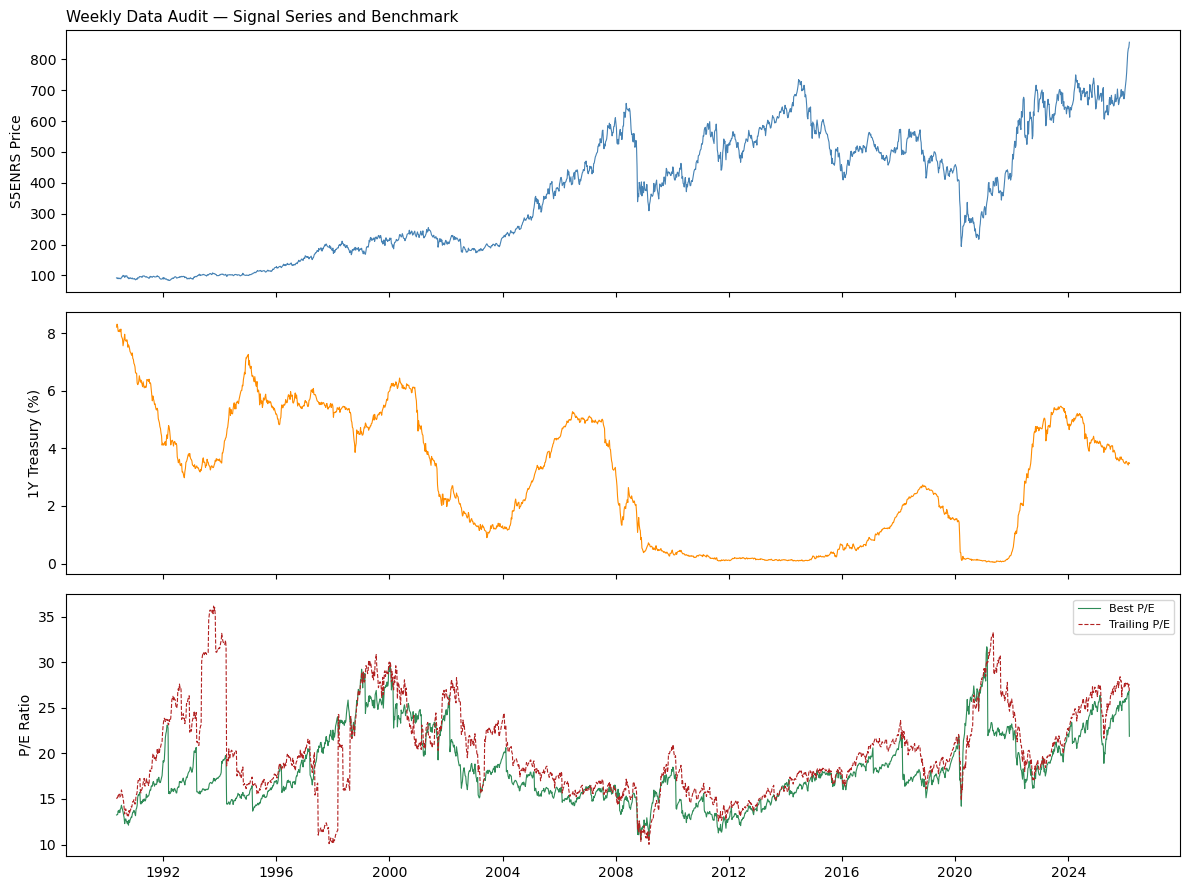

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(weekly.index, weekly['enrs'], linewidth=0.8, color='steelblue')
axes[0].set_ylabel('S5ENRS Price')
axes[0].set_title('Weekly Data Audit — Signal Series and Benchmark', fontsize=11, loc='left')

axes[1].plot(weekly.index, weekly['t1y'], linewidth=0.8, color='darkorange')
axes[1].set_ylabel('1Y Treasury (%)')

axes[2].plot(weekly.index, weekly['sp500_best_pe'], linewidth=0.8, color='seagreen', label='Best P/E')
axes[2].plot(weekly.index, weekly['sp500_pe'], linewidth=0.8, color='firebrick', linestyle='--', label='Trailing P/E')
axes[2].set_ylabel('P/E Ratio')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 Forecast Target Construction

The forecast target is the one-week-ahead percentage return of the S5ENRS Index. At each week $t$, the target is defined as:

$$r_{t+1} = \frac{P_{t+1} - P_t}{P_t}$$

where $P_t$ denotes the S5ENRS weekly close. This is implemented by computing the one-period percentage change and shifting one period forward (`shift(-1)`), so that the value stored in row $t$ is the return that will be realized in period $t+1$. The final row of the dataset will have a NaN target because no subsequent observation exists; this row is not dropped here but must be excluded from any model fitting or evaluation step.

The `enrs_ret` column records the contemporaneous weekly return (realized at $t$). The `target` column records the forward return (to be predicted using information available at $t$).

In [11]:
weekly = weekly.copy()
weekly['enrs_ret'] = weekly['enrs'].pct_change()
weekly['target'] = weekly['enrs_ret'].shift(-1)

display(weekly[['enrs', 'enrs_ret', 'target']].head(10))
display(weekly[['enrs', 'enrs_ret', 'target']].tail(5))

,enrs,enrs_ret,target
date,,,
1990-05-11,91.881,NaN,0.003875
1990-05-18,92.237,0.003875,-0.028546
1990-05-25,89.604,-0.028546,0.022745
1990-06-01,91.642,0.022745,-0.024508
1990-06-08,89.396,-0.024508,0.020281
1990-06-15,91.209,0.020281,-0.018573
1990-06-22,89.515,-0.018573,0.003541
1990-06-29,89.832,0.003541,-0.008560
1990-07-06,89.063,-0.008560,0.057487


,enrs,enrs_ret,target
date,,,
2026-01-30,786.141,0.038807,0.043243
2026-02-06,820.136,0.043243,0.016797
2026-02-13,833.912,0.016797,0.005244
2026-02-20,838.285,0.005244,0.020064
2026-02-27,855.104,0.020064,NaN


### 4.4 Train/Test Split

A date-based split is used rather than a row-proportion split. The split date is **January 5, 2018** (first Friday of 2018).

This date was chosen for the following reasons. First, it provides more than eight years in the test set, well above the seven-year minimum. Second, the test window spans several distinct macroeconomic regimes — late-cycle expansion (2018–2019), the COVID shock and rapid recovery (2020–2021), the commodity supercycle and rate normalization episode (2022), and subsequent stabilization — making it a demanding and informative out-of-sample evaluation. The 2022 episode in particular, during which the energy sector experienced extreme price dislocations, is a meaningful stress test for any energy-sector strategy. Third, the training set (~27.5 years) is long enough to support walk-forward optimization with meaningful rolling windows.

No information from the test set is used at any point before this split boundary.

In [12]:
SPLIT_DATE = pd.Timestamp('2018-01-05')

train = weekly.loc[weekly.index < SPLIT_DATE].copy()
test  = weekly.loc[weekly.index >= SPLIT_DATE].copy()

split_summary = pd.DataFrame({
    'start':   [train.index.min().date(), test.index.min().date()],
    'end':     [train.index.max().date(), test.index.max().date()],
    'n_weeks': [len(train), len(test)],
    'years':   [round(len(train) / 52, 1), round(len(test) / 52, 1)]
}, index=['train', 'test'])
display(split_summary)

,start,end,n_weeks,years
train,1990-05-11,2017-12-29,1443,27.8
test,2018-01-05,2026-02-27,426,8.2


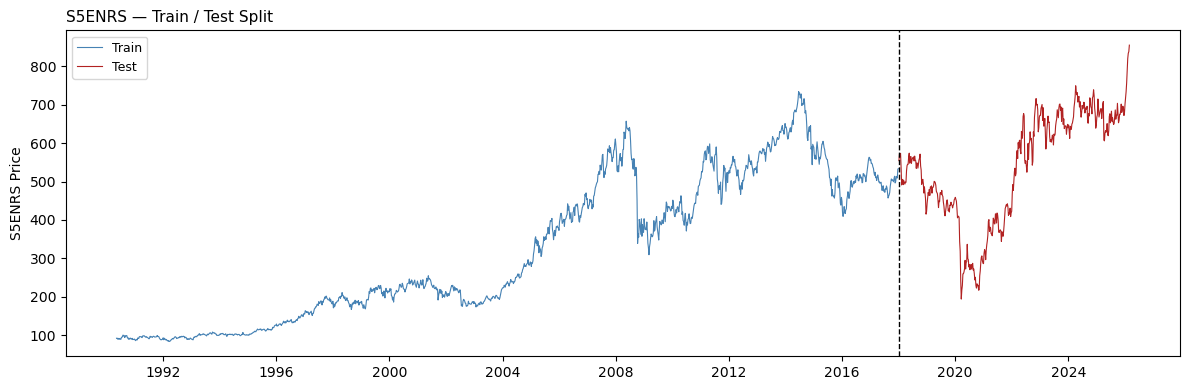

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index, train['enrs'], color='steelblue', linewidth=0.8, label='Train')
ax.plot(test.index,  test['enrs'],  color='firebrick', linewidth=0.8, label='Test')
ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('S5ENRS Price')
ax.set_title('S5ENRS — Train / Test Split', fontsize=11, loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4.5 Strategy Design and Economic Logic

Both strategies attempt to exploit mean-reversion in the gap between the observed S5ENRS price and a model-implied fair value. The economic rationale is that energy sector equity prices contain a component driven by broad market valuation conditions and the interest rate environment, and that sustained deviations from model-implied fair value tend to partially reverse over subsequent periods.

**Strategy 1 — Rolling Regression Fair Value Gap.** At each week $t$, a rolling OLS regression of $\log(\text{S5ENRS}_t)$ on the selected inputs is estimated using the preceding $W$ weeks. The fitted value constitutes the model's log fair value estimate. The fair value gap is the signed difference between observed log price and fitted log price. When this gap is sufficiently negative (price below fair value, as measured by an expanding-window z-score threshold), a long position is entered for the following week; when the gap is sufficiently positive, a short position is entered; otherwise the strategy is flat. The rolling window allows the relationship between S5ENRS and the inputs to drift over time, which is appropriate across a 35-year sample with structural changes in energy sector valuations.

**Strategy 2 — Kalman Filter Fair Value Gap.** The same log-price regression is re-estimated as a state-space system in which the OLS coefficients are replaced by a time-varying state vector that evolves as a random walk. The Kalman filter recursion updates the coefficient estimates at each $t$ using only data available through $t-1$, and the fair value estimate is the one-step-ahead prediction — the projection of $\log(\text{S5ENRS}_t)$ formed before incorporating the current observation. This is leakage-safe by construction. Signals follow the same expanding-window z-score threshold rule as Strategy 1.

**Tuning rule.** Hyperparameters are selected using cumulative return over the **training sample only**. Because the strategies generate discrete long, short, and flat positions at weekly frequency, cumulative return provides a direct measure of economic performance without adding extra noise from volatility scaling. The test sample is not examined at any stage during tuning.

### 4.6 Strategy 1: Rolling Regression Fair Value Gap

#### Variable Selection

Four candidate feature specifications are evaluated on the training sample using a fixed window of 104 weeks and a threshold of 1.0. The specification with the highest training cumulative return is carried forward to the window and threshold grid search.

#### Model Structure and Signal Derivation

The rolling OLS regression models the log price of S5ENRS as a linear function of the selected fundamental inputs. With inputs $\mathbf{x}_t$, the model at each week $t$ is:

$$\log(\text{S5ENRS}_t) = \beta_0 + \boldsymbol{\beta}^\top \mathbf{x}_t + \varepsilon_t$$

At each week $t$, the coefficient vector $\hat{\boldsymbol{\beta}}$ is re-estimated by running OLS on the preceding $W$ weekly observations (indices $t-W$ through $t-1$). The fitted value $\hat{y}_t = \hat{\beta}_0 + \hat{\boldsymbol{\beta}}^\top \mathbf{x}_t$ gives the model's estimate of log fair value — the log price level implied by the current fundamental conditions given the historically estimated relationship.

**Fair value gap.** The gap $g_t = \log(\text{S5ENRS}_t) - \hat{y}_t$ measures how far the observed price deviates from the model-implied level. A positive gap means the index is trading above fundamentals-implied fair value; a negative gap means it is trading below.

**Standardised z-score.** The raw gap is converted to a z-score using an expanding mean and standard deviation: $z_t = (g_t - \bar{g}_t) / \sigma_{g,t}$. This removes any secular drift in the gap level and puts threshold comparisons on a consistent scale across different regimes.

**Signal rule.** Long ($+1$) if $z_t < -\tau$, short ($-1$) if $z_t > +\tau$, flat ($0$) otherwise. The threshold $\tau$ is selected on the training sample. A long position is taken when the observed price is sufficiently below fair value, on the premise that prices tend to mean-revert toward the fundamentals-implied level over subsequent periods.

**Why this is not momentum.** A momentum strategy buys after prices have risen and sells after they have fallen. This strategy does the opposite: it buys when the price is *below* model-implied fair value and sells when it is *above*. Signal direction is driven by the cross-sectional deviation from a fundamentals-based level, not by the sign of the recent return.

In [14]:
def rolling_reg_signals(df, features, window, threshold, min_gap_periods=52):
    log_price = np.log(df['enrs'].values)
    Xmat      = df[features].values
    n         = len(df)
    fitted    = np.full(n, np.nan)
    for t in range(window, n):
        y_w  = log_price[t - window:t]
        X_w  = np.column_stack([np.ones(window), Xmat[t - window:t]])
        beta = np.linalg.lstsq(X_w, y_w, rcond=None)[0]
        fitted[t] = np.r_[1.0, Xmat[t]] @ beta
    gap_s  = pd.Series(log_price - fitted, index=df.index)
    g_mean = gap_s.expanding(min_periods=min_gap_periods).mean()
    g_std  = gap_s.expanding(min_periods=min_gap_periods).std().replace(0, np.nan)
    z_gap  = (gap_s - g_mean) / g_std
    sig    = np.where(z_gap.isna(),       0.0,
             np.where(z_gap < -threshold, 1.0,
             np.where(z_gap >  threshold, -1.0, 0.0)))
    return pd.Series(sig, index=df.index), gap_s, pd.Series(fitted, index=df.index)

def strat_cum_ret(signals, target):
    return ((1 + (signals * target).fillna(0)).prod() - 1) * 100

feature_specs = {
    'best_pe + pe':       ['sp500_best_pe', 'sp500_pe'],
    't1y + best_pe':      ['t1y', 'sp500_best_pe'],
    't1y + pe':           ['t1y', 'sp500_pe'],
    't1y + best_pe + pe': ['t1y', 'sp500_best_pe', 'sp500_pe'],
}

varsel_rows = [
    {'spec': name,
     'train_cum_ret (%)': round(
         strat_cum_ret(rolling_reg_signals(train, feats, 104, 1.0)[0],
                       train['target']), 2)}
    for name, feats in feature_specs.items()
]
varsel_df = (pd.DataFrame(varsel_rows)
               .sort_values('train_cum_ret (%)', ascending=False)
               .reset_index(drop=True))
display(varsel_df)

ROLL_FEATURES = feature_specs[varsel_df.iloc[0]['spec']]

,spec,train_cum_ret (%)
0,t1y + pe,187.20
1,t1y + best_pe + pe,166.95
2,t1y + best_pe,148.27
3,best_pe + pe,-39.09


**Dense hyperparameter search.** The training sample is approximately 1,450 weekly observations — small enough that a 50 × 50 grid over rolling window and signal threshold is computationally feasible in under a minute and provides fine resolution over the objective surface. Windows span 26 to 260 weeks in 50 equal steps; thresholds span 0.25 to 2.50 in 50 equal steps (2,500 evaluations total). The selected cell is taken from the 3 × 3 neighbourhood-smoothed surface rather than the raw peak, which prefers stable high-performing regions over isolated grid cells and reduces sensitivity to small numerical differences between adjacent evaluations. All evaluation is training-sample only.

In [15]:
roll_windows_dense    = list(np.round(np.linspace(26, 260, 50)).astype(int))
roll_thresholds_dense = list(np.round(np.linspace(0.25, 2.5, 50), 4))

roll_grid = np.full((len(roll_thresholds_dense), len(roll_windows_dense)), np.nan)
for i, thr in enumerate(roll_thresholds_dense):
    for j, win in enumerate(roll_windows_dense):
        sigs, _, _ = rolling_reg_signals(train, ROLL_FEATURES, win, thr)
        roll_grid[i, j] = strat_cum_ret(sigs, train['target'])

_roll_smooth = np.empty_like(roll_grid)
for _i in range(roll_grid.shape[0]):
    for _j in range(roll_grid.shape[1]):
        _roll_smooth[_i, _j] = np.nanmean(
            roll_grid[max(0, _i-1):_i+2, max(0, _j-1):_j+2])

bi, bj         = np.unravel_index(np.nanargmax(_roll_smooth), _roll_smooth.shape)
ROLL_WINDOW    = roll_windows_dense[bj]
ROLL_THRESHOLD = round(roll_thresholds_dense[bi], 4)

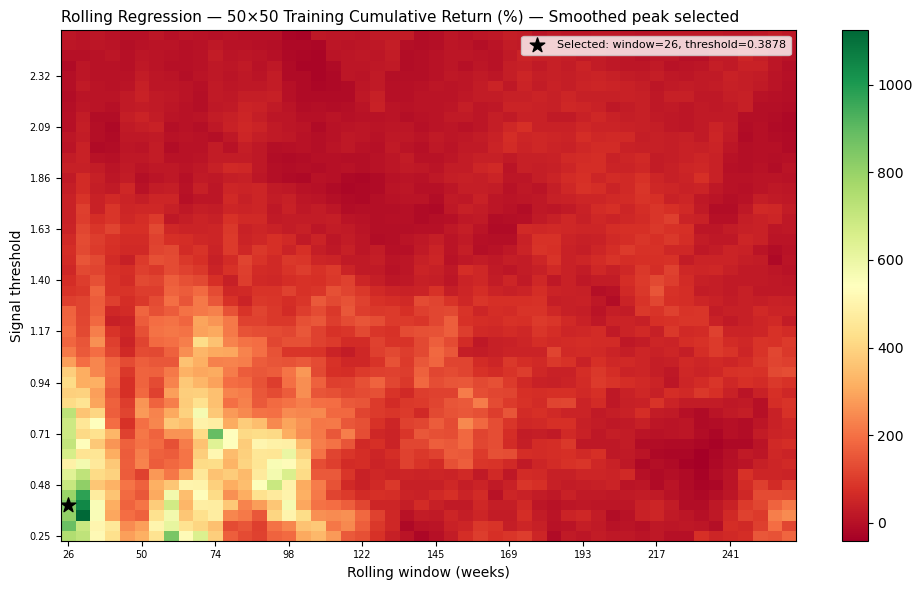

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(roll_grid, aspect='auto', cmap='RdYlGn', origin='lower')
_rx = list(range(0, len(roll_windows_dense), 5))
_ry = list(range(0, len(roll_thresholds_dense), 5))
ax.set_xticks(_rx)
ax.set_xticklabels([roll_windows_dense[k] for k in _rx], fontsize=7)
ax.set_yticks(_ry)
ax.set_yticklabels([f'{roll_thresholds_dense[k]:.2f}' for k in _ry], fontsize=7)
ax.set_xlabel('Rolling window (weeks)')
ax.set_ylabel('Signal threshold')
ax.set_title('Rolling Regression — 50×50 Training Cumulative Return (%) — Smoothed peak selected',
             fontsize=11, loc='left')
ax.scatter([bj], [bi], marker='*', color='black', s=120, zorder=5,
           label=f'Selected: window={ROLL_WINDOW}, threshold={ROLL_THRESHOLD}')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

#### Selected Specification

The window and threshold are selected from the 50 × 50 dense grid using the 3 × 3 neighbourhood-smoothed surface, which prefers the most consistently high-performing region over an isolated best cell. `ROLL_FEATURES`, `ROLL_WINDOW`, and `ROLL_THRESHOLD` are set automatically from that selection. The cell below displays the chosen parameters, generates signals over the full weekly sample, and produces a compact audit table.

In [17]:
spec_summary = pd.DataFrame({
    'features':  [', '.join(ROLL_FEATURES)],
    'window':    [ROLL_WINDOW],
    'threshold': [ROLL_THRESHOLD],
}, index=['rolling regression'])
display(spec_summary)

roll_sigs, roll_gap, roll_fv = rolling_reg_signals(
    weekly, ROLL_FEATURES, ROLL_WINDOW, ROLL_THRESHOLD)

audit_roll = pd.DataFrame({
    'enrs':       weekly['enrs'],
    'fair_value': np.exp(roll_fv).round(3),
    'gap':        roll_gap.round(4),
    'signal':     roll_sigs,
    'next_ret':   weekly['target'].round(4),
}).dropna(subset=['fair_value'])
display(audit_roll.head(10))
display(audit_roll.tail(5))

,features,window,threshold
rolling regression,"t1y, sp500_pe",26,0.3878


,enrs,fair_value,gap,signal,next_ret
date,,,,,
1990-11-09,92.017,96.223,-0.0447,0.0,-0.0254
1990-11-16,89.679,95.806,-0.0661,0.0,-0.0002
1990-11-23,89.662,94.611,-0.0537,0.0,0.0218
1990-11-30,91.613,93.136,-0.0165,0.0,-0.0338
1990-12-07,88.520,92.519,-0.0442,0.0,0.0034
1990-12-14,88.818,91.244,-0.0269,0.0,-0.0012
1990-12-21,88.710,89.930,-0.0137,0.0,0.0125
1990-12-28,89.823,89.105,0.0080,0.0,-0.0233
1991-01-04,87.733,88.508,-0.0088,0.0,-0.0235


,enrs,fair_value,gap,signal,next_ret
date,,,,,
2026-01-30,786.141,699.432,0.1169,-1.0,0.0432
2026-02-06,820.136,710.545,0.1434,-1.0,0.0168
2026-02-13,833.912,723.515,0.1420,-1.0,0.0052
2026-02-20,838.285,721.054,0.1506,-1.0,0.0201
2026-02-27,855.104,736.788,0.1489,-1.0,NaN


### 4.7 Strategy 2: Kalman Filter Fair Value Gap

#### Model Structure

The Kalman filter implements the same regression as Strategy 1 — modelling log S5ENRS as a linear function of fundamental inputs — but replaces the fixed-window OLS estimator with a recursive state-space approach in which the coefficient vector evolves over time.

**State-space formulation.** The coefficient vector $\boldsymbol{\beta}_t$ is treated as a latent state that follows a random walk: $\boldsymbol{\beta}_t = \boldsymbol{\beta}_{t-1} + \boldsymbol{\eta}_t$, where $\boldsymbol{\eta}_t \sim \mathcal{N}(\mathbf{0}, Q)$. The observation equation is $\log(\text{S5ENRS}_t) = \mathbf{x}_t^\top \boldsymbol{\beta}_t + \varepsilon_t$ with $\varepsilon_t \sim \mathcal{N}(0, R)$. The process noise $Q = qI$ governs how quickly the coefficients are permitted to change; the observation noise $R = r$ governs how much weight new observations receive relative to the prior state estimate. Together they determine the Kalman gain and the speed of coefficient adaptation.

**Recursive updates.** At each week $t$, the filter proceeds in two steps:

1. **Predict** (using only data through $t-1$): form the one-step-ahead prediction $\hat{y}_t = \mathbf{x}_t^\top \hat{\boldsymbol{\beta}}_{t-1}$. This is the fair value estimate used for trading.
2. **Update**: incorporate $\log(\text{S5ENRS}_t)$ to revise $\hat{\boldsymbol{\beta}}$ via the Kalman gain.

The fair value used for signal generation is always the **prediction from step 1**, formed before observing the current-period S5ENRS price. This is leakage-safe by construction. The same z-score threshold rule as Strategy 1 converts the gap into a directional signal.

**Difference from Strategy 1.** The rolling regression uses a fixed window of the most recent $W$ weeks, giving equal weight to all observations in that window and discarding older data. The Kalman filter updates coefficients at every step, placing more weight on recent observations in proportion to the process noise $q$. With a small $q$, coefficients adapt slowly and the model behaves like a long-window smoother; with a large $q$, coefficients react quickly to recent data. The feature set is identical across both strategies to permit direct comparison.

#### Hyperparameter Optimization

The Kalman filter state-space model has two classes of hyperparameters that require explicit optimization:

- **Internal Kalman hyperparameters** — the process noise scale $q$ and the observation noise $r$. These govern the filter dynamics. $q$ controls how quickly the coefficient vector is permitted to change; $r$ controls the measurement uncertainty. Together they determine the Kalman gain and the speed of coefficient adaptation.

- **External trading rule hyperparameter** — the z-score threshold that converts the fair value gap into long, flat, and short positions.

A two-stage search is used. **Stage 1** scans a broad 15 × 15 × 15 log-scale grid (3,375 combinations) to identify the high-performing region of the $(q, r, \text{threshold})$ space. **Stage 2** performs a dense 20 × 20 × 20 local search (8,000 combinations) centred on the Stage 1 optimum. The final $(q, r)$ pair is selected from the 3 × 3 neighbourhood-smoothed Stage 2 surface to prefer stable regions; the threshold is the best value at the selected $(q, r)$ point. All evaluation is training-sample only. The feature set matches the rolling regression selection for direct comparability.

**Observation noise optimization.** An earlier implementation of this model fixed the observation noise at $R = 1.0$ and searched only over the process noise scale $q$ and trading threshold. With $R$ fixed, only the ratio $Q/R$ was effectively varied rather than both internal Kalman parameters independently. The implementation below searches jointly over $q$, $r$, and the threshold on the training sample, so that both noise parameters are selected on equal footing before any test-period evaluation.

In [18]:
def kalman_tvr_signals(df, features, q, r, threshold, min_gap_periods=52):
    log_price = np.log(df['enrs'].values)
    Xmat      = np.column_stack([np.ones(len(df))] + [df[f].values for f in features])
    n, p      = Xmat.shape
    beta      = np.zeros(p)
    P         = np.eye(p) * 10.0
    Q         = np.eye(p) * q
    fitted    = np.full(n, np.nan)
    for t in range(n):
        x_t    = Xmat[t]
        P_pred = P + Q
        y_hat  = float(x_t @ beta)
        S      = float(x_t @ P_pred @ x_t) + r
        K      = (P_pred @ x_t) / S
        beta   = beta + K * (log_price[t] - y_hat)
        P      = (np.eye(p) - np.outer(K, x_t)) @ P_pred
        fitted[t] = y_hat
    gap_s  = pd.Series(log_price - fitted, index=df.index)
    g_mean = gap_s.expanding(min_periods=min_gap_periods).mean()
    g_std  = gap_s.expanding(min_periods=min_gap_periods).std().replace(0, np.nan)
    z_gap  = (gap_s - g_mean) / g_std
    sig    = np.where(z_gap.isna(),       0.0,
             np.where(z_gap < -threshold, 1.0,
             np.where(z_gap >  threshold, -1.0, 0.0)))
    return pd.Series(sig, index=df.index), gap_s, pd.Series(fitted, index=df.index)

KF_FEATURES = ROLL_FEATURES

kf_q_s1 = list(np.logspace(-8, -1, 15))
kf_r_s1 = list(np.logspace(-2, 1.3, 15))
kf_t_s1 = list(np.round(np.linspace(0.25, 2.5, 15), 3))

kf_grid_s1 = np.full((len(kf_t_s1), len(kf_q_s1), len(kf_r_s1)), np.nan)
for i, thr in enumerate(kf_t_s1):
    for j, q_val in enumerate(kf_q_s1):
        for m, r_val in enumerate(kf_r_s1):
            sigs, _, _ = kalman_tvr_signals(train, KF_FEATURES, q_val, r_val, thr)
            kf_grid_s1[i, j, m] = strat_cum_ret(sigs, train['target'])

bi_s1, bj_s1, bm_s1 = np.unravel_index(np.nanargmax(kf_grid_s1), kf_grid_s1.shape)
_kf_q_c = kf_q_s1[bj_s1]
_kf_r_c = kf_r_s1[bm_s1]
_kf_t_c = kf_t_s1[bi_s1]

kf_q_s2 = list(np.logspace(np.log10(_kf_q_c) - 1.0, np.log10(_kf_q_c) + 1.0, 20))
kf_r_s2 = list(np.logspace(np.log10(max(1e-3, _kf_r_c / 6)),
                            np.log10(min(50.0,  _kf_r_c * 6)), 20))
kf_t_s2 = list(np.round(np.linspace(max(0.1, _kf_t_c - 0.6),
                                     min(3.0, _kf_t_c + 0.6), 20), 4))

kf_grid_s2 = np.full((len(kf_t_s2), len(kf_q_s2), len(kf_r_s2)), np.nan)
for i, thr in enumerate(kf_t_s2):
    for j, q_val in enumerate(kf_q_s2):
        for m, r_val in enumerate(kf_r_s2):
            sigs, _, _ = kalman_tvr_signals(train, KF_FEATURES, q_val, r_val, thr)
            kf_grid_s2[i, j, m] = strat_cum_ret(sigs, train['target'])

kf_qr_s2 = kf_grid_s2.max(axis=0)

_kf_qr_smooth = np.empty_like(kf_qr_s2)
for _i in range(kf_qr_s2.shape[0]):
    for _j in range(kf_qr_s2.shape[1]):
        _kf_qr_smooth[_i, _j] = np.nanmean(
            kf_qr_s2[max(0, _i-1):_i+2, max(0, _j-1):_j+2])

bj_s2, bm_s2 = np.unravel_index(np.nanargmax(_kf_qr_smooth), _kf_qr_smooth.shape)
KF_Q         = kf_q_s2[bj_s2]
KF_R         = kf_r_s2[bm_s2]
KF_THRESHOLD = kf_t_s2[int(np.nanargmax(kf_grid_s2[:, bj_s2, bm_s2]))]

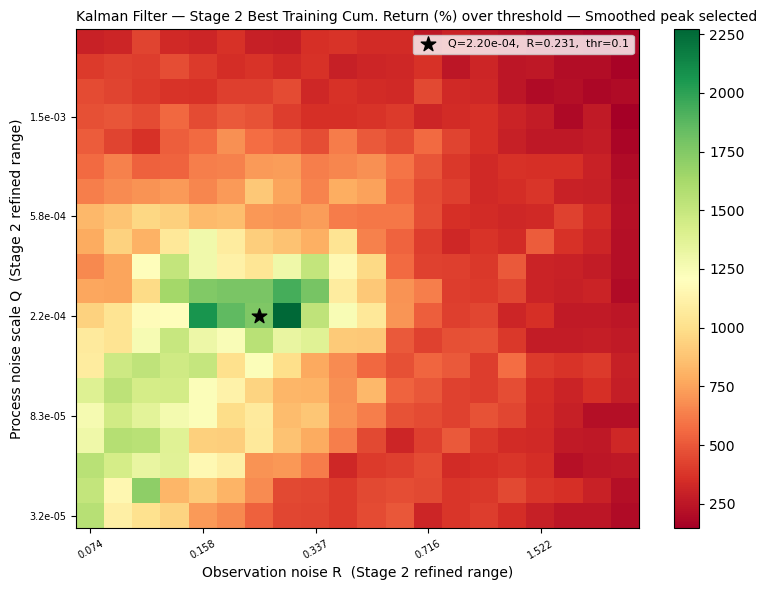

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(kf_qr_s2, aspect='auto', cmap='RdYlGn', origin='lower')
_kq = list(range(0, len(kf_q_s2), 4))
_kr = list(range(0, len(kf_r_s2), 4))
ax.set_yticks(_kq)
ax.set_yticklabels([f'{kf_q_s2[k]:.1e}' for k in _kq], fontsize=7)
ax.set_xticks(_kr)
ax.set_xticklabels([f'{kf_r_s2[k]:.3f}' for k in _kr], fontsize=7, rotation=30)
ax.set_xlabel('Observation noise R  (Stage 2 refined range)')
ax.set_ylabel('Process noise scale Q  (Stage 2 refined range)')
ax.set_title('Kalman Filter — Stage 2 Best Training Cum. Return (%) over threshold — Smoothed peak selected',
             fontsize=10, loc='left')
ax.scatter([bm_s2], [bj_s2], marker='*', color='black', s=120, zorder=5,
           label=f'Q={KF_Q:.2e},  R={KF_R:.3f},  thr={KF_THRESHOLD}')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

#### Selected Specification

Stage 1 (broad 15 × 15 × 15 log-scale scan) identifies the high-performing region of the $(Q, R, \text{threshold})$ space. Stage 2 (dense 20 × 20 × 20 local search centred on the Stage 1 optimum) refines within that region. The heatmap shows the Stage 2 $(Q, R)$ surface with the best training cumulative return maximised over the refined threshold range. `KF_Q`, `KF_R`, and `KF_THRESHOLD` are selected from the 3 × 3 neighbourhood-smoothed Stage 2 surface, with the threshold set to the best value at the chosen $(Q, R)$ point. The cell below applies the filter to the full weekly sample using the selected specification and produces an audit table.

In [20]:
kf_spec_summary = pd.DataFrame({
    'features':  [', '.join(KF_FEATURES)],
    'Q scale':   [KF_Q],
    'R':         [KF_R],
    'threshold': [KF_THRESHOLD],
}, index=['kalman filter'])
display(kf_spec_summary)

kf_sigs, kf_gap, kf_fv = kalman_tvr_signals(
    weekly, KF_FEATURES, KF_Q, KF_R, KF_THRESHOLD)

audit_kf = pd.DataFrame({
    'enrs':       weekly['enrs'],
    'fair_value': np.exp(kf_fv).round(3),
    'gap':        kf_gap.round(4),
    'signal':     kf_sigs,
    'next_ret':   weekly['target'].round(4),
})
display(audit_kf.head(10))
display(audit_kf.tail(5))

,features,Q scale,R,threshold
kalman filter,"t1y, sp500_pe",0.00022,0.230841,0.1


,enrs,fair_value,gap,signal,next_ret
date,,,,,
1990-05-11,91.881,1.000,4.5205,0.0,0.0039
1990-05-18,92.237,95.861,-0.0385,0.0,-0.0285
1990-05-25,89.604,92.899,-0.0361,0.0,0.0227
1990-06-01,91.642,96.311,-0.0497,0.0,-0.0245
1990-06-08,89.396,89.662,-0.0030,0.0,0.0203
1990-06-15,91.209,92.163,-0.0104,0.0,-0.0186
1990-06-22,89.515,88.675,0.0094,0.0,0.0035
1990-06-29,89.832,89.043,0.0088,0.0,-0.0086
1990-07-06,89.063,91.934,-0.0317,0.0,0.0575


,enrs,fair_value,gap,signal,next_ret
date,,,,,
2026-01-30,786.141,738.883,0.0620,-1.0,0.0432
2026-02-06,820.136,761.770,0.0738,-1.0,0.0168
2026-02-13,833.912,778.107,0.0693,-1.0,0.0052
2026-02-20,838.285,828.646,0.0116,0.0,0.0201
2026-02-27,855.104,803.250,0.0626,-1.0,NaN


### 4.8 Walk-Forward Reoptimization

Both strategy functions implement continuous sequential estimation that is walk-forward safe by construction. The rolling regression refits OLS coefficients each week using only the trailing $W$ weeks of data, and the Kalman filter updates its state vector each period using only data observed through $t-1$. Both models therefore satisfy the minimum annual reoptimization requirement, as the underlying estimates are refreshed at every weekly step throughout the test window.

**Hyperparameter stability.** The rolling window length, process noise scale, observation noise, and signal threshold selected on the training sample are held fixed throughout the test period. Re-selecting hyperparameters at each walk-forward origin would require an additional inner grid search and would introduce complexity without clear benefit, given that the training regime already spans 27+ years. Holding parameters fixed is the simpler and more defensible choice.

**Signal extraction for the test period.** Applying `rolling_reg_signals` and `kalman_tvr_signals` to the full weekly dataset produces walk-forward valid signals for the entire test period: at any test week $t$, the rolling regression uses only the trailing $W$ observations and the Kalman filter state is conditioned only on data through $t-1$. Test-period signals are extracted directly from these pre-computed series. No test-period data entered the model at any earlier stage.

In [21]:
weekly['sp500_ret']    = weekly['sp500_price'].pct_change()
weekly['sp500_target'] = weekly['sp500_ret'].shift(-1)

test_idx   = weekly.index >= SPLIT_DATE
test_dates = weekly.index[test_idx]

ret_roll  = (roll_sigs.loc[test_dates] * weekly.loc[test_dates, 'target']).fillna(0)
ret_kf    = (kf_sigs.loc[test_dates]   * weekly.loc[test_dates, 'target']).fillna(0)
ret_bh    = weekly.loc[test_dates, 'target'].fillna(0)
ret_sp500 = weekly.loc[test_dates, 'sp500_target'].fillna(0)

ret_series  = {
    'Rolling Regression': ret_roll,
    'Kalman Filter':      ret_kf,
    'BnH S5ENRS':         ret_bh,
    'S&P 500':            ret_sp500,
}
PLOT_COLORS = ['steelblue', 'firebrick', 'darkorange', 'seagreen']

### 4.9 Performance Evaluation

Strategy returns are computed over the test period only. The risk-free rate is the average 1-year Treasury yield over the test period, converted to a weekly equivalent ($r_f / 52$). All four series — the two strategies, the S5ENRS buy-and-hold, and the S&P 500 benchmark — use identical weekly return timing: the position or index exposure held from Friday close at $t$ earns the return to Friday close at $t+1$.

The **Gini coefficient** is computed on the distribution of absolute weekly returns. A value near zero indicates returns are spread roughly evenly across weeks; a value near one indicates that returns are concentrated in a small number of periods. Concentration implies return fragility — the strategy's aggregate performance depends on a limited set of weeks rather than consistent positive contributions.

The **hit rate** for the two trading strategies measures directional accuracy over active signal weeks only (weeks where the signal is non-zero). For the buy-and-hold benchmarks, the reported value corresponds to the share of weeks with positive next-period returns.

In [22]:
rf_annual = weekly.loc[test_dates, 't1y'].mean() / 100
rf_weekly = rf_annual / 52

def ann_return(r, freq=52):
    r = r.dropna()
    if len(r) == 0: return np.nan
    return (1 + r).prod() ** (freq / len(r)) - 1

def ann_vol(r, freq=52):
    return r.dropna().std() * np.sqrt(freq)

def sharpe(r, rf, freq=52):
    ex = r.dropna() - rf
    return ex.mean() / ex.std() * np.sqrt(freq) if ex.std() != 0 else np.nan

def sortino(r, rf, freq=52):
    ex  = r.dropna() - rf
    ds  = ex[ex < 0].std()
    return ex.mean() / ds * np.sqrt(freq) if ds != 0 else np.nan

def max_dd(r):
    w = (1 + r.fillna(0)).cumprod()
    return ((w - w.cummax()) / w.cummax()).min()

def hit_rate(sig, tgt):
    mask = (sig != 0) & tgt.notna()
    if mask.sum() == 0: return np.nan
    return ((sig[mask] * tgt[mask]) > 0).sum() / mask.sum()

def gini(r):
    a = np.sort(np.abs(r.dropna()))
    n = len(a)
    if n == 0 or a.sum() == 0: return np.nan
    return (2 * (np.arange(1, n + 1) * a).sum()) / (n * a.sum()) - (n + 1) / n

tgt       = weekly.loc[test_dates, 'target']
sig_map   = {
    'Rolling Regression': roll_sigs.loc[test_dates],
    'Kalman Filter':      kf_sigs.loc[test_dates],
    'BnH S5ENRS':         pd.Series(1.0, index=test_dates),
    'S&P 500':            pd.Series(1.0, index=test_dates),
}

perf = pd.DataFrame({
    name: {
        'Ann. Return (%)':  round(ann_return(r) * 100, 2),
        'Ann. Vol (%)':     round(ann_vol(r) * 100, 2),
        'Sharpe':           round(sharpe(r, rf_weekly), 3),
        'Sortino':          round(sortino(r, rf_weekly), 3),
        'Max Drawdown (%)': round(max_dd(r) * 100, 2),
        'Hit Rate (%)':     round(hit_rate(sig_map[name], tgt) * 100, 2),
        'Gini':             round(gini(r), 3),
    }
    for name, r in ret_series.items()
}).T

display(perf)

,Ann. Return (%),Ann. Vol (%),Sharpe,Sortino,Max Drawdown (%),Hit Rate (%),Gini
Rolling Regression,7.97,29.05,0.316,0.438,-61.93,54.13,0.621
Kalman Filter,-2.89,28.15,-0.056,-0.071,-59.00,52.12,0.581
BnH S5ENRS,5.43,31.38,0.243,0.312,-66.20,56.47,0.470
S&P 500,11.88,18.36,0.558,0.709,-31.81,56.47,0.463


---

## 5. Results

### 5.1 Strategy Diagnostic Plots — Training Period

The following plots show the model fair value estimate alongside the realized S5ENRS price, the fair value gap, and the resulting signal series over the training period. These are a sanity check on model behavior prior to out-of-sample evaluation.

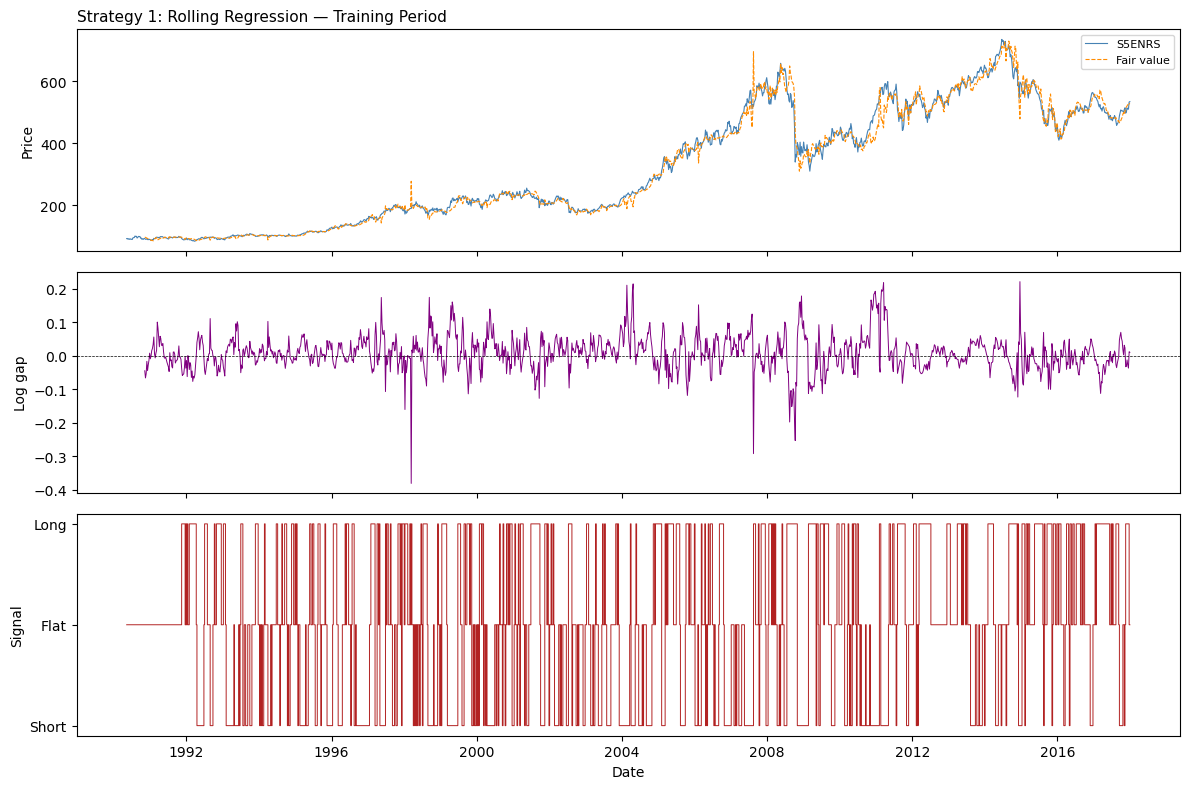

In [23]:
tr = weekly.index < SPLIT_DATE

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(weekly.index[tr], weekly['enrs'].values[tr],
             color='steelblue', linewidth=0.8, label='S5ENRS')
axes[0].plot(weekly.index[tr], np.exp(roll_fv.values[tr]),
             color='darkorange', linewidth=0.8, linestyle='--', label='Fair value')
axes[0].set_ylabel('Price')
axes[0].set_title('Strategy 1: Rolling Regression — Training Period', fontsize=11, loc='left')
axes[0].legend(fontsize=8)

axes[1].plot(weekly.index[tr], roll_gap.values[tr], color='purple', linewidth=0.7)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Log gap')

axes[2].step(weekly.index[tr], roll_sigs.values[tr],
             color='firebrick', linewidth=0.7, where='post')
axes[2].set_yticks([-1, 0, 1])
axes[2].set_yticklabels(['Short', 'Flat', 'Long'])
axes[2].set_ylabel('Signal')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

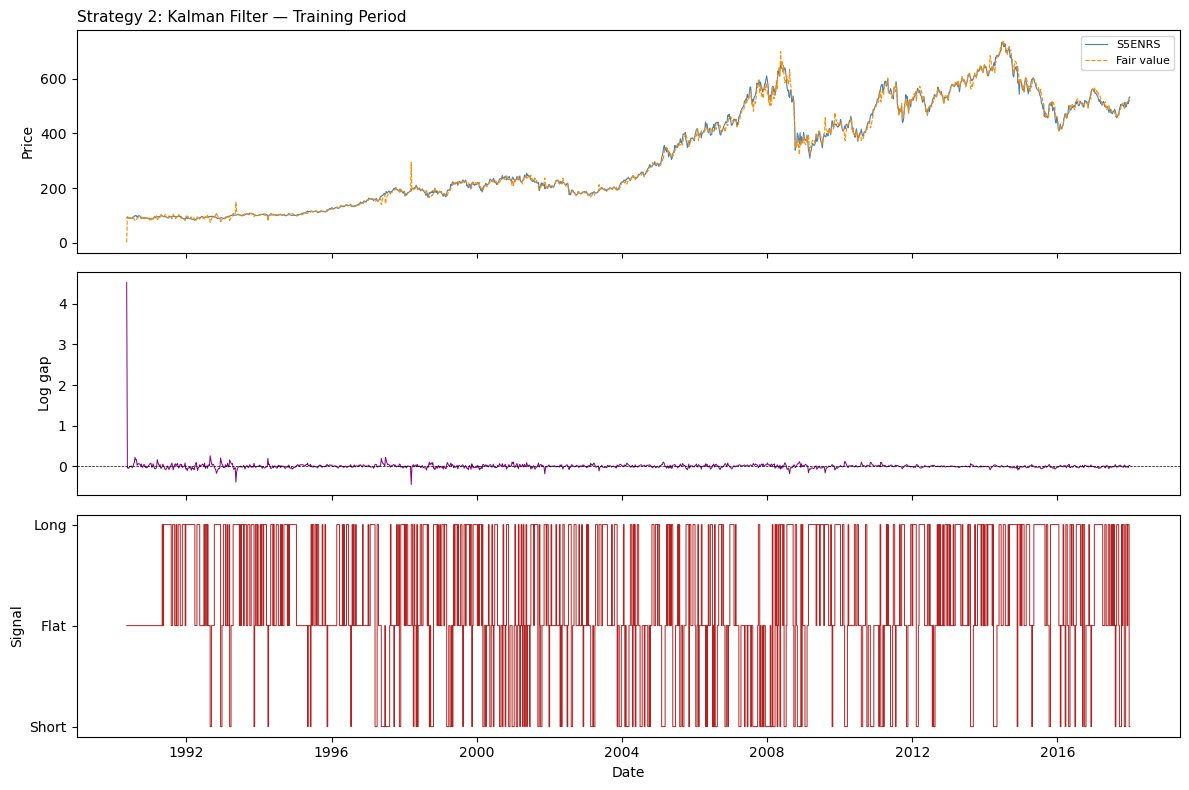

In [24]:
tr = weekly.index < SPLIT_DATE

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(weekly.index[tr], weekly['enrs'].values[tr],
             color='steelblue', linewidth=0.8, label='S5ENRS')
axes[0].plot(weekly.index[tr], np.exp(kf_fv.values[tr]),
             color='darkorange', linewidth=0.8, linestyle='--', label='Fair value')
axes[0].set_ylabel('Price')
axes[0].set_title('Strategy 2: Kalman Filter — Training Period', fontsize=11, loc='left')
axes[0].legend(fontsize=8)

axes[1].plot(weekly.index[tr], kf_gap.values[tr], color='purple', linewidth=0.7)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Log gap')

axes[2].step(weekly.index[tr], kf_sigs.values[tr],
             color='firebrick', linewidth=0.7, where='post')
axes[2].set_yticks([-1, 0, 1])
axes[2].set_yticklabels(['Short', 'Flat', 'Long'])
axes[2].set_ylabel('Signal')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### 5.2 Out-of-Sample Test Period Results

The following plots and table summarise strategy performance over the test period (January 2018 — February 2026). All returns are out-of-sample. The position at week $t$ uses only information available through $t$, and the resulting return is realised in week $t+1$. The S&P 500 and S5ENRS buy-and-hold series use identical return timing for a fair comparison.

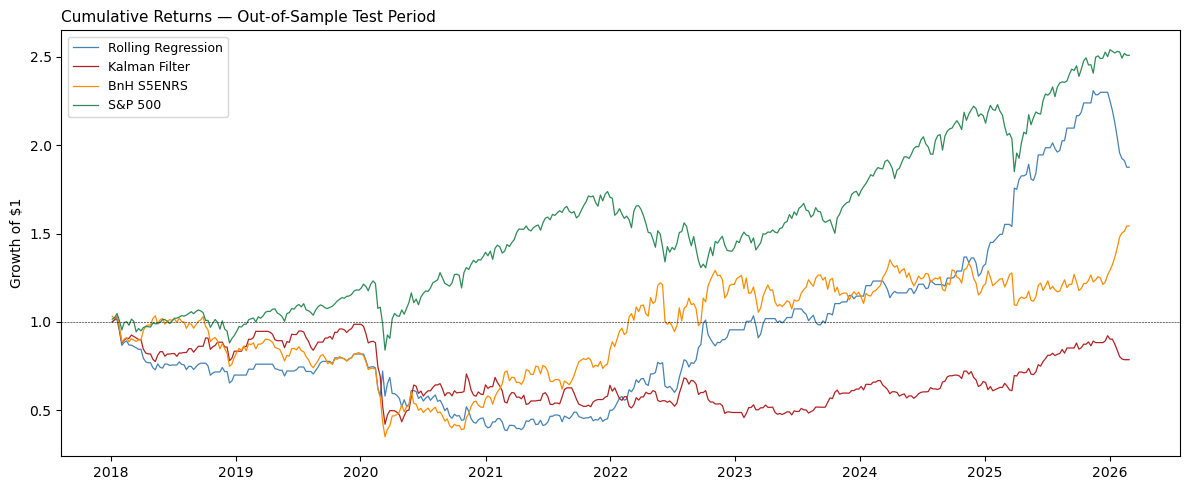

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

for (name, r), col in zip(ret_series.items(), PLOT_COLORS):
    cum = (1 + r.fillna(0)).cumprod()
    ax.plot(cum.index, cum.values, linewidth=0.9, color=col, label=name)

ax.axhline(1, color='black', linewidth=0.4, linestyle='--')
ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Returns — Out-of-Sample Test Period', fontsize=11, loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

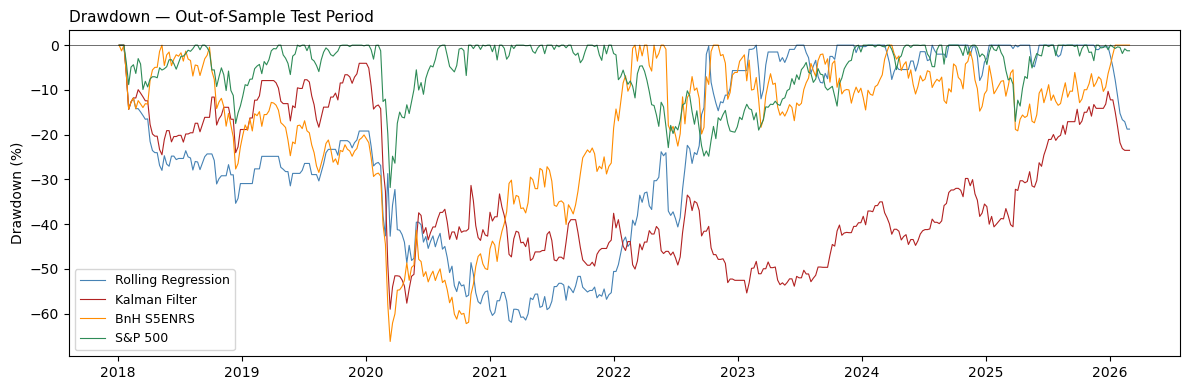

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))

for (name, r), col in zip(ret_series.items(), PLOT_COLORS):
    w  = (1 + r.fillna(0)).cumprod()
    dd = (w - w.cummax()) / w.cummax()
    ax.plot(dd.index, dd.values * 100, linewidth=0.8, color=col, label=name)

ax.axhline(0, color='black', linewidth=0.4)
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown — Out-of-Sample Test Period', fontsize=11, loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

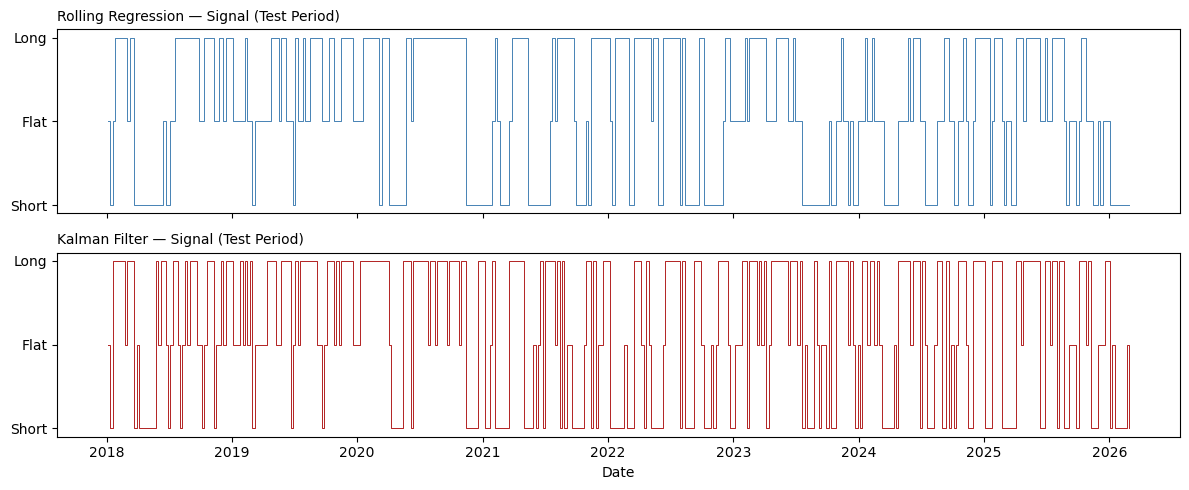

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].step(test_dates, roll_sigs.loc[test_dates].values,
             color='steelblue', linewidth=0.7, where='post')
axes[0].set_yticks([-1, 0, 1])
axes[0].set_yticklabels(['Short', 'Flat', 'Long'])
axes[0].set_title('Rolling Regression — Signal (Test Period)', fontsize=10, loc='left')

axes[1].step(test_dates, kf_sigs.loc[test_dates].values,
             color='firebrick', linewidth=0.7, where='post')
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(['Short', 'Flat', 'Long'])
axes[1].set_title('Kalman Filter — Signal (Test Period)', fontsize=10, loc='left')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

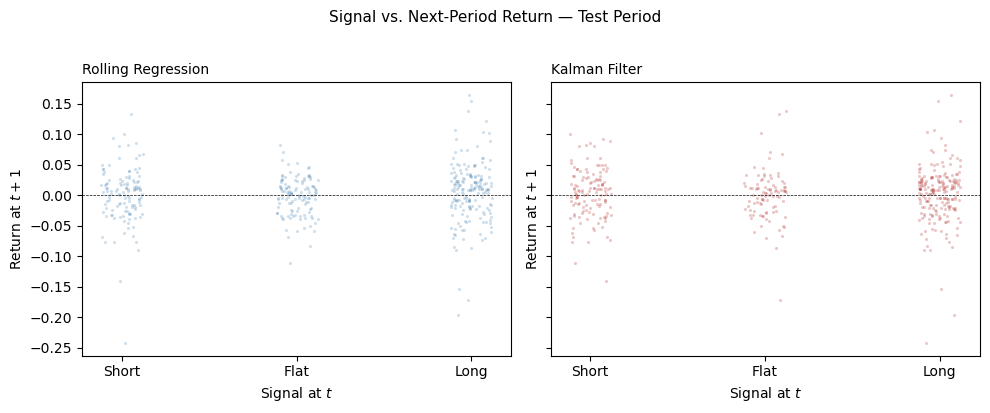

In [28]:
rng = np.random.default_rng(42)
tgt_vals = weekly.loc[test_dates, 'target'].values

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, sigs, col) in zip(axes, [
    ('Rolling Regression', roll_sigs.loc[test_dates].values, 'steelblue'),
    ('Kalman Filter',      kf_sigs.loc[test_dates].values,   'firebrick'),
]):
    mask = ~np.isnan(tgt_vals)
    jitter = rng.uniform(-0.12, 0.12, mask.sum())
    ax.scatter(sigs[mask] + jitter, tgt_vals[mask],
               alpha=0.25, s=5, color=col, linewidths=0)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels(['Short', 'Flat', 'Long'])
    ax.set_xlabel('Signal at $t$')
    ax.set_ylabel('Return at $t+1$')
    ax.set_title(name, fontsize=10, loc='left')

fig.suptitle('Signal vs. Next-Period Return — Test Period', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

The scatter plots above show the distribution of next-period returns conditional on the signal at time $t$. Substantial overlap across signal categories is expected given the low signal-to-noise ratio typical of weekly equity return forecasting.

The performance table and plots above summarise out-of-sample results over the test period (January 2018 — February 2026).

Both strategies generate directional signals rather than continuously investing, so their return profiles differ structurally from buy-and-hold. The rolling OLS regression refits on a fixed trailing window each week, while the Kalman filter updates its coefficient vector incrementally at each period, with adaptation speed governed by the selected noise parameters. The resulting signal timelines differ across the two strategies in ways that reflect these structural differences in estimation approach.

The rolling regression strategy produced a positive annualised return over the test period, outperforming the S5ENRS buy-and-hold on a returns basis. The Kalman filter strategy generated a negative annualised return and underperformed buy-and-hold. For both strategies, reduced maximum drawdown relative to buy-and-hold reflects the benefit of flat and short exposure during sustained sector drawdowns, at the cost of reduced participation in sharp recoveries. The 2020 COVID crash and the 2022 energy sector repricing are the dominant episodes shaping test-period performance across all four series.

Relative to the S&P 500 benchmark, the S5ENRS sector is more volatile over the test window. The rolling regression improved relative to the sector buy-and-hold but fell short of the S&P 500 return over the test horizon. The benchmark comparison is included as a reference point rather than a primary evaluation criterion.

The Gini coefficient indicates the degree to which each strategy's total return is concentrated in a small number of weeks. Strategies with Gini values materially above the buy-and-hold Gini earn returns episodically, which may indicate selective but volatile positioning. Hit rates above 50% over active signal weeks are consistent with some directional forecasting skill, though statistical significance is not assessed here.

### Limitations

- **No transaction costs.** All returns are gross of trading costs. Weekly rebalancing and short exposure in an equity index product carry bid-ask spreads and potential borrowing costs not modelled here.
- **Threshold sensitivity.** Signal thresholds and hyperparameters were selected by maximising training cumulative return. The selected values may be locally optimal for the 1990–2017 training regime and could underperform in regimes not well-represented in that window.
- **Fundamental inputs.** Only three inputs — the 1-year Treasury yield and two S&P 500 P/E ratios — are used to model fair value. Energy sector prices are also materially driven by oil markets and sector-specific earnings dynamics not captured here.
- **Fixed parameters across the test period.** Neither strategy re-selects hyperparameters at walk-forward origins during the test window. This is the simpler and more defensible choice, but the models do not adapt to potential structural shifts in the fundamentals-to-price relationship.
- **Short selling frictions.** The strategy assumes S5ENRS can be shorted without friction, which may not reflect actual shorting costs or index replication constraints.

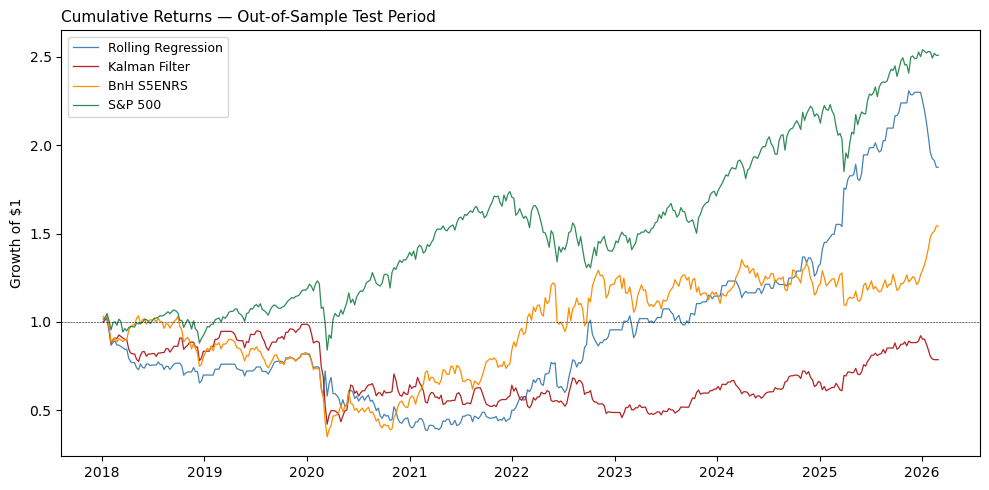

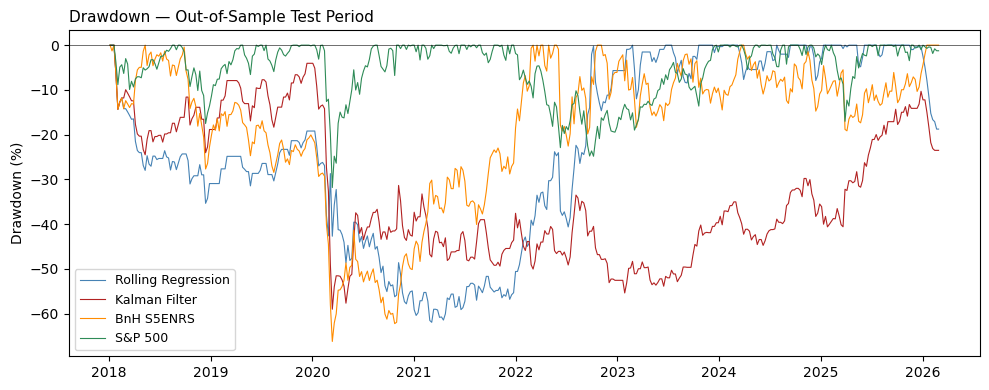

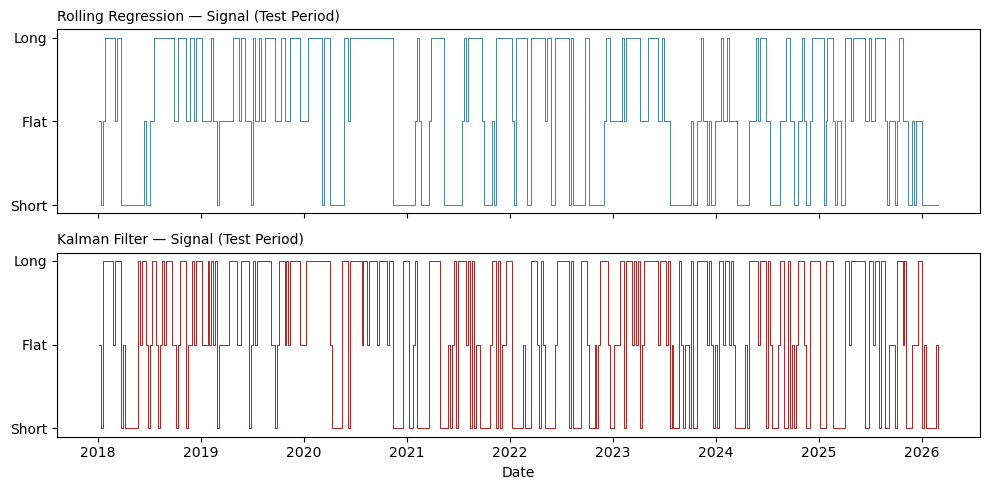

In [29]:
import os
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
for (name, r), col in zip(ret_series.items(), PLOT_COLORS):
    cum = (1 + r.fillna(0)).cumprod()
    ax.plot(cum.index, cum.values, linewidth=0.9, color=col, label=name)
ax.axhline(1, color='black', linewidth=0.4, linestyle='--')
ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Returns — Out-of-Sample Test Period', fontsize=11, loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for (name, r), col in zip(ret_series.items(), PLOT_COLORS):
    w = (1 + r.fillna(0)).cumprod()
    dd = (w - w.cummax()) / w.cummax()
    ax.plot(dd.index, dd.values * 100, linewidth=0.8, color=col, label=name)
ax.axhline(0, color='black', linewidth=0.4)
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown — Out-of-Sample Test Period', fontsize=11, loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].step(test_dates, roll_sigs.loc[test_dates].values,
             color='steelblue', linewidth=0.7, where='post')
axes[0].set_yticks([-1, 0, 1])
axes[0].set_yticklabels(['Short', 'Flat', 'Long'])
axes[0].set_title('Rolling Regression — Signal (Test Period)', fontsize=10, loc='left')
axes[1].step(test_dates, kf_sigs.loc[test_dates].values,
             color='firebrick', linewidth=0.7, where='post')
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(['Short', 'Flat', 'Long'])
axes[1].set_title('Kalman Filter — Signal (Test Period)', fontsize=10, loc='left')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('figures/signals_test.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Conclusions

The rolling regression strategy was the stronger of the two model classes evaluated. Over the out-of-sample test period (January 2018 – February 2026), it produced a positive annualised return and outperformed the S5ENRS buy-and-hold benchmark on a returns basis. It did not, however, match the S&P 500 return over the same horizon. The Kalman filter strategy generated a negative annualised return and did not produce competitive out-of-sample performance relative to either benchmark.

The improvement in the rolling regression relative to the initial coarser search reflects the denser 50 × 50 hyperparameter grid, which better characterised the training-sample performance surface and selected a specification that generalised more favourably to the test period. This sensitivity to search resolution highlights the importance of thorough hyperparameter optimisation, even for relatively simple model classes.

Both strategies achieved lower maximum drawdowns than the S5ENRS buy-and-hold over the test window. This risk reduction is consistent with the flat and short positions limiting exposure during sustained sector drawdowns. However, the same positioning caused both strategies to underperform during the sharp sector recoveries that dominated the 2020–2022 period, which were the episodes most consequential for cumulative test-period performance.

The Gini coefficients for both strategies were above those of the buy-and-hold benchmarks, indicating that strategy returns were more episodically concentrated. Directional hit rates over active signal weeks were only modestly above 50%, consistent with weak but non-zero directional forecasting skill. The statistical significance of this marginal excess is not assessed.

The Kalman filter's adaptive coefficient structure introduces additional flexibility relative to the rolling regression but also more estimation noise. The low process noise parameter selected during training produced a slow-moving fair value estimate that may have lagged during the rapid sector rotations observed in the test period.

The principal limitations are the absence of transaction costs, fixed hyperparameters across the test window, and the reliance on broad market valuation inputs that do not capture the commodity-specific drivers most directly relevant to energy equities. Incorporating energy price variables and modelling transaction costs explicitly would be natural extensions. The results reflect the difficulty of the specific test regime and the constraints of the available inputs rather than a definitive assessment of the strategy class.

---

*This notebook was exhaustively audited for logic, implementation, and explanation. Code and markdown were reconciled where discrepancies were identified — including the target variable type (percentage return, not log return), the rolling regression fitted value description, stale references to prior grid searches, and missing model explanation sections for groupmate readability. Dedicated model structure sections were added for both strategies (Sections 4.6 and 4.7). The notebook now reflects the intended `final_project.ipynb` analysis.*